Clustering

In [3]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([
    [1.5,2.0],
    [2.0,1.5],
    [2.5,2.5],
    [1.8,3.0],
    [7.5,8.0],
    [8.0,7.5],
    [8.5,8.5],
    [9.0,7.8]
])

print(x)

[[1.5 2. ]
 [2.  1.5]
 [2.5 2.5]
 [1.8 3. ]
 [7.5 8. ]
 [8.  7.5]
 [8.5 8.5]
 [9.  7.8]]


In [4]:
c0=np.array([2,2])
c1=np.array([8,8])

print("c0: ",c0)
print("c1 :",c1)

c0:  [2 2]
c1 : [8 8]


In [5]:
labels=[]

for point in x:
    d0=np.sqrt((point[0]-c0[0])**2+(point[1]-c0[1])**2)
    d1=np.sqrt((point[0]-c1[0])**2+(point[1]-c1[1])**2)

    if d0<d1:
        labels.append(0)
        cluster=0
    else:
        labels.append(1)
        cluster=1

    print(f"{point}\t{d0:.2f}\t\t{d1:.2f}\t\t{cluster}")

labels=np.array(labels)

[1.5 2. ]	0.50		8.85		0
[2.  1.5]	0.50		8.85		0
[2.5 2.5]	0.71		7.78		0
[1.8 3. ]	1.02		7.96		0
[7.5 8. ]	8.14		0.50		1
[8.  7.5]	8.14		0.50		1
[8.5 8.5]	9.19		0.71		1
[9.  7.8]	9.09		1.02		1


In [6]:
centroids =np.array([c0,c1])

iteration =1

while True:

    print("="*50)
    print(f"Iteration {iteration}")
    print("="*50)

    labels=[]

    for point in x:
        distances=[]

        for centroid in centroids:
            distance = np.sqrt(np.sum((point-centroid)**2))
            distances.append(distance)

        labels.append(np.argmin(distances))
    
    labels=np.array(labels)

    new_centroids=[]

    for i in range(len(centroids)):

        cluster=x[labels==i]

        centroid=np.mean(cluster,axis=0)

        new_centroids.append(centroid)

    new_centroids=np.array(new_centroids)

    print("Old Centroids")

    print(centroids)

    print()

    if np.allclose(centroids,new_centroids):
        print("Converged Successfully")

        break

    centroids=new_centroids
    iteration+=1
    

Iteration 1
Old Centroids
[[2 2]
 [8 8]]

Iteration 2
Old Centroids
[[1.95 2.25]
 [8.25 7.95]]

Converged Successfully


In [7]:
wcss=0

for i in range(len(centroids)):
    cluster=x[labels==i]

    for point in cluster:
        distance=np.sum((point-centroids[i])**2)

        wcss +=distance

print("Final wcss = ",wcss)

Final wcss =  3.5599999999999996


In [8]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=2, n_init='auto', random_state=42)


In [9]:
model.fit(x)

c:\Users\jeeva\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


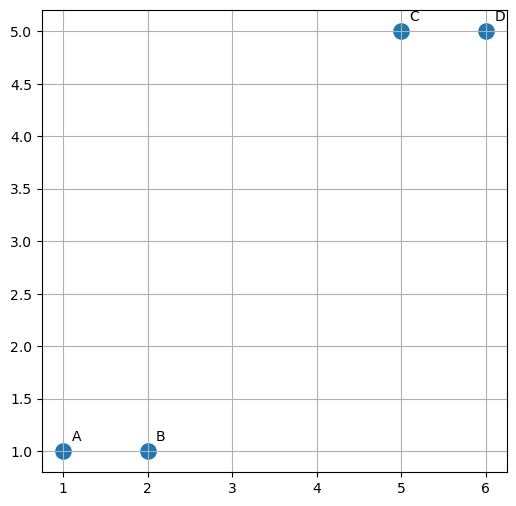

In [10]:
import matplotlib.pyplot as plt

x=np.array([
    [1,1],
    [2,1],
    [5,5],
    [6,5]
])

labels=['A','B','C','D']

plt.figure(figsize=(6,6))

plt.scatter(x[:,0],x[:,1],s=120)

for i,label in enumerate(labels):
    plt.text(x[i,0]+0.1,x[i,1]+0.1,label)

plt.grid(True)
plt.show()

In [11]:
from scipy.cluster.hierarchy import linkage

z=linkage(
    x,
    method='single'
)

print(z)

[[0. 1. 1. 2.]
 [2. 3. 1. 2.]
 [4. 5. 5. 4.]]


In [13]:
import pandas as pd

columns=[
    "Cluster 1",
    "Cluster 2",
    "Distance",
    "Points in Cluster"
]

pd.DataFrame(z,columns=columns)

,Cluster 1,Cluster 2,Distance,Points in Cluster
0,0.0,1.0,1.0,2.0
1,2.0,3.0,1.0,2.0
2,4.0,5.0,5.0,4.0


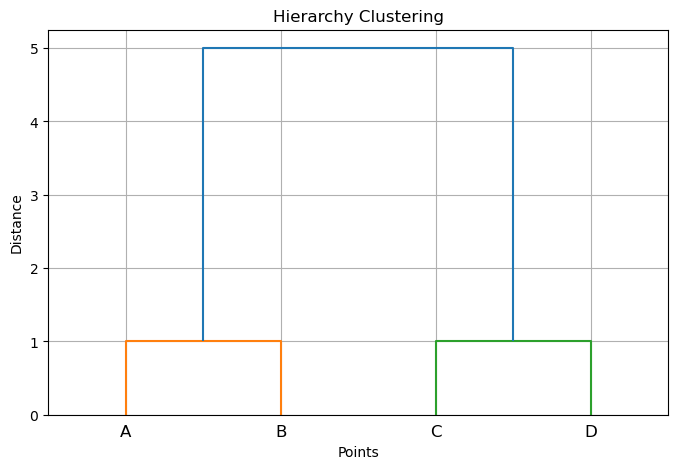

In [14]:
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(8,5))

dendrogram(
    z,
    labels=labels
)

plt.title("Hierarchy Clustering")

plt.xlabel("Points")
plt.ylabel("Distance")

plt.grid(True)

plt.show()

In [15]:
from sklearn.cluster import AgglomerativeClustering

model=AgglomerativeClustering(
    n_clusters=2,
    linkage="single"
)

clusters=model.fit_predict(x)

print(clusters)

[1 1 0 0]
